# Energy Consumption Forecasting
## TCN + Multi-Head Attention + BiLSTM Model

This notebook builds a hybrid deep learning pipeline to forecast daily energy consumption using London climate data. The architecture combines three powerful sequence modelling components:

- **Temporal Convolutional Network (TCN)** — Captures local temporal patterns with dilated causal convolutions
- **Multi-Head Self-Attention** — Identifies long-range dependencies across the input window
- **Bidirectional LSTM** — Extracts forward and backward sequential context

---

### Notebook Structure
| Part | Description |
|------|-------------|
| 1 | Data Loading & Feature Engineering |
| 2 | Model Architecture Definition |
| 3 | Model Training |
| 4 | Evaluation on Test Set |
| 5 | Visualisations & Summary |

## Environment Setup

Suppress TensorFlow verbose logs and set global random seeds to ensure reproducibility across NumPy, TensorFlow operations, and weight initialisation.

In [7]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Hyperparameters

All tunable hyperparameters are defined in one place for easy experimentation. Key design decisions:

- **`WINDOW_SIZE = 45`** — The model sees 45 days of history before making each prediction; longer context captures seasonal lag effects
- **`BATCH_SIZE = 16`** — Small batches introduce gradient noise which improves generalisation on small tabular datasets
- **`DILATIONS = [1, 2, 4, 8]`** — Four dilation levels give the TCN a receptive field of `(3-1) × (1+2+4+8) × 2 = 60` time steps, fully covering the window
- **`DROPOUT = 0.1`** — Light regularisation to avoid over-smoothing predictions
- **`L2 = 1e-5`** — Minimal weight decay keeps the model expressive

In [8]:
# ── Hyperparameters (single place to tune) ───────────────────
WINDOW_SIZE  = 45       # longer context = more signal for lag features
BATCH_SIZE   = 16       # smaller batch → noisier gradients → better generalisation on small datasets
EPOCHS       = 300      # early stopping governs actual stop
TCN_FILTERS  = 128      # wider TCN
TCN_KERNEL   = 3
DILATIONS    = [1, 2, 4, 8]   # kept at 4 levels — receptive field already covers window
LSTM_UNITS   = 96
DROPOUT      = 0.1      # reduced across the board to prevent over-regularisation
DENSE_UNITS  = 64
L2           = 1e-5     # lighter regularisation

---
## Part 1 — Data Loading & Feature Engineering

### 1.1 Load & Merge Datasets

Two CSVs are loaded:
- `london_climate.csv` — daily climate variables (temperature, rainfall, solar radiation, ET0)
- `preprocessed_example.csv` — daily energy consumption figures

They are merged on the `Date` column (inner join), sorted chronologically, and the index is reset to produce a clean, contiguous daily time series.

In [9]:
climate     = pd.read_csv('../Data/london_climate.csv')
consumption = pd.read_csv('water_consumption_preprocessed.csv')

climate['Date']     = pd.to_datetime(climate['Date']).dt.date
consumption['Date'] = pd.to_datetime(consumption['Date']).dt.date

df = pd.merge(consumption, climate, on='Date', how='inner')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Merged dataset shape: {df.shape}")
df.head()

Merged dataset shape: (2004, 10)


,Date,Consumption,Temp_Mean,Temp_Max,Temp_Min,Precipitation,Rainfall,Wind_Speed,ET0,Solar_Radiation
0,2015-01-01,98343.49626,-5.543417,-2.883,-8.433001,0.000000,0.000000,31.056128,1.180087,4.59
1,2015-01-02,98343.69374,-2.745500,-0.633,-3.983000,0.000000,0.000000,23.000591,0.876756,5.99
2,2015-01-03,98684.73359,-1.049667,4.067,-4.033000,18.099997,13.099998,20.188908,0.294635,0.81
3,2015-01-04,98684.84818,1.317000,3.917,-5.633000,8.300000,6.000000,28.146843,0.297200,2.04
4,2015-01-05,98685.22039,-12.037168,-6.483,-14.433001,0.000000,0.000000,29.598919,0.682800,7.04


### 1.2 Feature Engineering

Raw climate variables alone are insufficient — we construct a rich feature set:

| Feature Group | Variables | Rationale |
|---|---|---|
| **Temperature derived** | `temp_range`, `temp_avg`, `heat_index` | Captures thermal stress and solar interaction |
| **Cyclical time** | `day_sin/cos`, `month_sin/cos`, `doy_sin/cos` | Preserves circular continuity (Mon↔Sun, Dec↔Jan) without ordinal boundary errors |
| **Calendar flags** | `is_weekend`, `quarter` | Accounts for weekly demand patterns and seasonal billing |
| **Rolling consumption** | 7d/14d/30d mean, 7d std | Autoregressive signal — where we've been predicts where we're going |
| **Climate rolling** | `temp_7d_avg`, `rain_7d_sum` | Smoothed weather signal reduces noise |

> **Leakage prevention**: All rolling consumption stats use `.shift(1)` before windowing, so today's consumption never leaks into its own predictors.

In [10]:
# ── Feature Engineering ──────────────────────────────────────
# Temp features
df['temp_range']     = df['Temp_Max'] - df['Temp_Min']
df['temp_avg']       = (df['Temp_Max'] + df['Temp_Min']) / 2
df['heat_index']     = df['Temp_Max'] * df['Solar_Radiation']

# Cyclical time encodings (no ordinal boundary errors)
df['day_sin']        = np.sin(2 * np.pi * df['Date'].dt.dayofweek / 7)
df['day_cos']        = np.cos(2 * np.pi * df['Date'].dt.dayofweek / 7)
df['month_sin']      = np.sin(2 * np.pi * df['Date'].dt.month / 12)
df['month_cos']      = np.cos(2 * np.pi * df['Date'].dt.month / 12)
df['doy_sin']        = np.sin(2 * np.pi * df['Date'].dt.dayofyear / 365)
df['doy_cos']        = np.cos(2 * np.pi * df['Date'].dt.dayofyear / 365)

# Calendar flags
df['is_weekend']     = (df['Date'].dt.dayofweek >= 5).astype(float)
df['quarter']        = df['Date'].dt.quarter / 4.0   # normalised 0.25–1.0

# Rolling statistics (all shifted by 1 to avoid leakage)
df['rolling_7d_mean']  = df['Consumption'].shift(1).rolling(7,  min_periods=1).mean()
df['rolling_14d_mean'] = df['Consumption'].shift(1).rolling(14, min_periods=1).mean()
df['rolling_7d_std']   = df['Consumption'].shift(1).rolling(7,  min_periods=1).std().fillna(0)
df['rolling_30d_mean'] = df['Consumption'].shift(1).rolling(30, min_periods=1).mean()

# Climate rolling features
df['temp_7d_avg']    = df['Temp_Max'].rolling(7,  min_periods=1).mean()
df['rain_7d_sum']    = df['Rainfall'].rolling(7,  min_periods=1).sum()

df = df.dropna().reset_index(drop=True)

print(f"Rows after feature engineering: {len(df)}")

Rows after feature engineering: 2003


### 1.3 Feature Selection & Scaling

We assemble the final feature list and apply **RobustScaler** independently to features and target.

**Why RobustScaler?** Unlike StandardScaler, it uses the interquartile range rather than mean/variance, making it resilient to outliers — a common occurrence in weather and consumption data (e.g., heatwaves, public holidays).

In [11]:
feature_cols = [
    # Climate
    'Temp_Max', 'Rainfall', 'ET0', 'Solar_Radiation',
    'temp_range', 'temp_avg', 'heat_index',
    'temp_7d_avg', 'rain_7d_sum',
    # Cyclical time
    'day_sin', 'day_cos',
    'month_sin', 'month_cos',
    'doy_sin', 'doy_cos',
    # Calendar flags
    'is_weekend', 'quarter',
    # Rolling consumption stats
    'rolling_7d_mean', 'rolling_14d_mean', 'rolling_30d_mean', 'rolling_7d_std',
]

print(f"Base features: {len(feature_cols)}")

# ── Scaling ──────────────────────────────────────────────────
scaler_x = RobustScaler()
scaler_y = RobustScaler()

scaled_features    = scaler_x.fit_transform(df[feature_cols])
scaled_target      = scaler_y.fit_transform(df[['Consumption']])
scaled_consumption = scaled_target.flatten()

Base features: 21


### 1.4 Lag Features

Explicit lag features give the model direct access to past consumption values as inputs. Lags are constructed **after** scaling (so they operate in the scaled domain) and **before** window creation (so each window already contains the relevant lags).

Lags used: **1, 2, 3, 7, 14, 21, 28 days** — covering yesterday, the recent trend, and seasonal weekly comparisons up to a month ago.

> The first `max(LAG_DAYS)` rows are dropped as warmup to avoid zero-padded lags entering training.

In [12]:
# ── Leak-free Lag Features ───────────────────────────────────
LAG_DAYS = [1, 2, 3, 7, 14, 21, 28]   # richer autoregressive signal

lag_matrix = np.zeros((len(scaled_consumption), len(LAG_DAYS)))
for j, lag in enumerate(LAG_DAYS):
    lag_matrix[lag:, j] = scaled_consumption[:-lag]

scaled_features = np.hstack([scaled_features, lag_matrix])
feature_cols    = feature_cols + [f'lag_{d}d' for d in LAG_DAYS]
NUM_FEATURES    = len(feature_cols)

print(f"Total features (incl. lags): {NUM_FEATURES}")

Total features (incl. lags): 28


### 1.5 Sliding Window & Train/Test Split

A **sliding window** transforms the time series into supervised learning samples:
- Each sample `X[i]` = 45 consecutive rows of features
- Each target `y[i]` = the consumption value on day `i + WINDOW_SIZE`

The split is **strictly chronological** (70% train / 30% test) — no shuffling — to simulate real-world deployment where the model predicts future unseen data.

In [13]:
# ── Windowing ────────────────────────────────────────────────
def create_windows(f_data, t_data, window):
    x, y = [], []
    for i in range(len(f_data) - window):
        x.append(f_data[i:i+window])
        y.append(t_data[i+window])
    return np.array(x), np.array(y)

X, y   = create_windows(scaled_features, scaled_target, window=WINDOW_SIZE)
warmup = max(LAG_DAYS)
X, y   = X[warmup:], y[warmup:]

# ── 70/30 Chronological Split ────────────────────────────────
split           = int(len(X) * 0.7)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Input shape      : {X_train.shape}")

Training samples : 1351
Test samples     : 579
Input shape      : (1351, 45, 28)


### 1.6 Feature Overview Plot

Two diagnostic charts:
1. **Lag alignment** — Verifies lag features track the consumption signal with the correct offset (no leakage)
2. **Correlation bar chart** — Pearson correlation of every feature against consumption, sorted to reveal the most predictive inputs

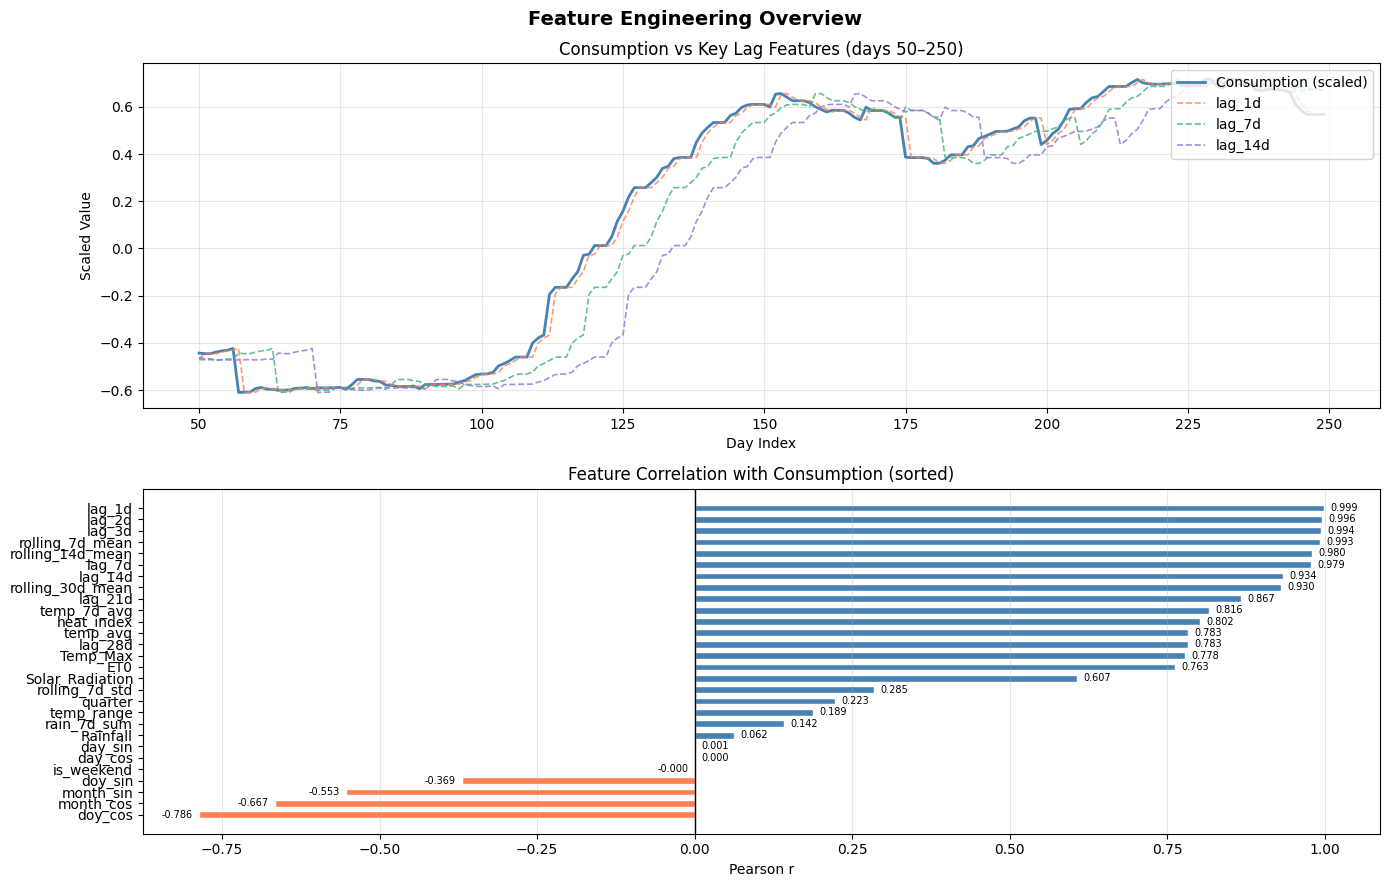

Plot saved → feature_overview.png


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Feature Engineering Overview', fontsize=14, fontweight='bold')

ax1 = axes[0]
plot_range = range(50, 250)
ax1.plot(plot_range, scaled_consumption[50:250],
         label='Consumption (scaled)', color='steelblue', lw=2)
for lag, color in zip([1, 7, 14], ['coral', 'mediumseagreen', 'mediumpurple']):
    lag_idx = feature_cols.index(f'lag_{lag}d')
    ax1.plot(plot_range, scaled_features[50:250, lag_idx],
             label=f'lag_{lag}d', lw=1.2, linestyle='--', color=color, alpha=0.8)
ax1.set_title('Consumption vs Key Lag Features (days 50–250)')
ax1.set_xlabel('Day Index')
ax1.set_ylabel('Scaled Value')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
feature_df = pd.DataFrame(scaled_features, columns=feature_cols)
corr       = feature_df.corrwith(pd.Series(scaled_consumption, name='Consumption')).sort_values()
colors_bar = ['coral' if v < 0 else 'steelblue' for v in corr.values]
bars = ax2.barh(corr.index, corr.values, color=colors_bar, edgecolor='white', height=0.6)
ax2.axvline(0, color='black', lw=1)
ax2.set_title('Feature Correlation with Consumption (sorted)')
ax2.set_xlabel('Pearson r')
ax2.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, corr.values):
    ax2.text(val + (0.01 if val >= 0 else -0.01),
             bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center',
             ha='left' if val >= 0 else 'right', fontsize=7)

plt.tight_layout()
plt.savefig('feature_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → feature_overview.png")

---
## Part 2 — Model Architecture

The model is a three-stage hybrid:

```
Input (45, 28)
    │
    ▼
Conv1D projection → LayerNorm          # align channels to TCN_FILTERS
    │
    ▼
TCN Residual Blocks × 4 (dilations 1,2,4,8)
    │
    ▼
Multi-Head Self-Attention (4 heads)
    │
    ▼
BiLSTM (96 units) → LayerNorm
    │
    ▼
BiLSTM (48 units)
    │
    ▼
Dense(64, relu) → Dropout → Dense(32, relu) → Dense(1)
```

### 2.1 TCN Residual Block

Each TCN block applies **two dilated causal convolutions** with a skip connection. Key details:
- **Causal padding** — ensures no future information leaks into past time steps
- **GELU activation** — smoother gradient flow than ReLU
- **SpatialDropout1D** — drops entire feature maps, more effective for sequences than regular dropout
- **1×1 residual projection** — if input/output channel sizes differ, a pointwise conv aligns them before the skip Add

In [15]:
# ── TCN Residual Block ───────────────────────────────────────
def tcn_residual_block(x, filters, kernel_size, dilation_rate, dropout_rate):
    residual = x

    x = layers.Conv1D(
        filters         = filters,
        kernel_size     = kernel_size,
        dilation_rate   = dilation_rate,
        padding         = 'causal',
        kernel_initializer = 'he_normal',
        kernel_regularizer = regularizers.l2(L2)
    )(x)
    x = layers.LayerNormalization()(x)
    x = layers.Activation('gelu')(x)
    x = layers.SpatialDropout1D(dropout_rate)(x)

    x = layers.Conv1D(
        filters         = filters,
        kernel_size     = kernel_size,
        dilation_rate   = dilation_rate,
        padding         = 'causal',
        kernel_initializer = 'he_normal',
        kernel_regularizer = regularizers.l2(L2)
    )(x)
    x = layers.LayerNormalization()(x)
    x = layers.Activation('gelu')(x)
    x = layers.SpatialDropout1D(dropout_rate)(x)

    if residual.shape[-1] != filters:
        residual = layers.Conv1D(filters=filters, kernel_size=1, padding='same')(residual)

    return layers.Add()([x, residual])

### 2.2 Multi-Head Self-Attention Block

Self-attention allows every time step to attend to every other step in the window simultaneously — unlike LSTMs that process sequentially. This is particularly useful for picking up **long-range dependencies** (e.g., same day last week correlating with today).

The output is added back to the input (residual connection) and layer-normalised, following the standard Transformer block pattern.

In [16]:
# ── Multi-Head Self-Attention Block ─────────────────────────
def attention_block(x, num_heads=4):
    d_model  = x.shape[-1]
    attended = layers.MultiHeadAttention(
        num_heads = num_heads,
        key_dim   = max(1, d_model // num_heads),
        dropout   = DROPOUT
    )(x, x)
    x = layers.Add()([x, attended])
    x = layers.LayerNormalization()(x)
    return x

### 2.3 Build & Compile the Full Model

The five stages are connected into a single Keras functional model:

1. **Input projection** — Projects `NUM_FEATURES` → `TCN_FILTERS` channels so all TCN blocks have consistent dimensions
2. **TCN blocks** — Dilated convolutions at rates 1, 2, 4, 8
3. **Attention** — Global context over the entire 45-day window
4. **BiLSTM ×2** — First layer returns sequences; second returns a single context vector
5. **Regression head** — Dense layers funnel the representation down to a scalar prediction

**Loss: Huber** — A hybrid of MSE (for large errors) and MAE (for small errors), more robust to outliers than pure MSE.

**Optimiser: Adam with gradient clipping** (`clipnorm=1.0`) prevents exploding gradients during early training.

In [17]:
# ── Build Model ──────────────────────────────────────────────
def build_model():
    inputs = layers.Input(shape=(WINDOW_SIZE, NUM_FEATURES), name='input_sequence')

    # ── Stage 1: Input projection ────────────────────────────
    x = layers.Conv1D(TCN_FILTERS, kernel_size=1, padding='same',
                      kernel_initializer='he_normal')(inputs)
    x = layers.LayerNormalization()(x)

    # ── Stage 2: TCN Blocks ──────────────────────────────────
    for d in DILATIONS:
        x = tcn_residual_block(x, TCN_FILTERS, TCN_KERNEL, d, DROPOUT)

    # ── Stage 3: Multi-Head Self-Attention ───────────────────
    x = attention_block(x, num_heads=4)

    # ── Stage 4: BiLSTM ─────────────────────────────────────
    x = layers.Bidirectional(
        layers.LSTM(
            LSTM_UNITS,
            return_sequences  = True,
            dropout           = DROPOUT,
            recurrent_dropout = 0.0,        # recurrent_dropout disables cuDNN — keep 0
            kernel_regularizer = regularizers.l2(L2)
        ),
        name='bilstm_1'
    )(x)
    x = layers.LayerNormalization()(x)

    x = layers.Bidirectional(
        layers.LSTM(
            LSTM_UNITS // 2,
            return_sequences  = False,
            dropout           = DROPOUT,
            kernel_regularizer = regularizers.l2(L2)
        ),
        name='bilstm_2'
    )(x)

    # ── Stage 5: Dense Regression Head ──────────────────────
    x = layers.Dense(DENSE_UNITS, activation='relu',
                     kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.Dropout(DROPOUT)(x)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(1, name='consumption_output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='TCN_Attn_BiLSTM_v2')
    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
        loss      = 'huber',
        metrics   = ['mae']
    )
    return model


model = build_model()
model.summary()

rf = sum((TCN_KERNEL - 1) * d * 2 for d in DILATIONS)
print(f"\nTCN Receptive Field : {rf} days")
print(f"Window Size         : {WINDOW_SIZE} days")
print(f"Total Features      : {NUM_FEATURES}")

with open('model_summary.txt', 'w', encoding='utf-8') as f:
    model.summary(print_fn=lambda line: f.write(line + '\n'))
print("Model summary saved → model_summary.txt")

Model: "TCN_Attn_BiLSTM_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 45, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 45, 128)   │      3,712 │ input_sequence[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 45, 128)   │        256 │ conv1d[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 45, 128)   │     49,280 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 45, 128)   │        256 │ conv1d_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 45, 128)   │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 45, 128)   │          0 │ activation[0][0]  │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 45, 128)   │     49,280 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 45, 128)   │        256 │ conv1d_2[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 45, 128)   │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 45, 128)   │          0 │ activation_1[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 45, 128)   │          0 │ spatial_dropout1… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 45, 128)   │     49,280 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 45, 128)   │        256 │ conv1d_3[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 45, 128)   │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 45, 128)   │          0 │ activation_2[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 45, 128)   │     49,280 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 45, 128)   │        256 │ conv1d_4[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 740,609 (2.83 MB)

 Trainable params: 740,609 (2.83 MB)

 Non-trainable params: 0 (0.00 B)


TCN Receptive Field : 60 days
Window Size         : 45 days
Total Features      : 28


Model summary saved → model_summary.txt


---
## Part 3 — Training

Three callbacks govern training:

| Callback | Purpose |
|---|---|
| **EarlyStopping** (patience=30) | Halts training when val_loss stops improving, restores best weights automatically |
| **ReduceLROnPlateau** (patience=10, factor=0.5) | Halves the learning rate after 10 stagnant epochs — fine-tunes convergence without manual scheduling |
| **ModelCheckpoint** | Saves the best model weights to disk during training so they survive any runtime interruption |

15% of the training data is held out as a **validation set** (chronologically — the last 15% of training rows) to monitor generalisation.

In [18]:
callbacks = [
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 30,
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor   = 'val_loss',
        factor    = 0.5,
        patience  = 10,
        min_lr    = 1e-7,
        verbose   = 1
    ),
    ModelCheckpoint(
        filepath       = 'best_tcn_bilstm.keras',
        monitor        = 'val_loss',
        save_best_only = True,
        verbose        = 0
    )
]

print("\n" + "="*55)
print("TRAINING  TCN + Attention + BiLSTM  (best config)")
print("="*55)

history = model.fit(
    X_train, y_train,
    validation_split = 0.15,
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    callbacks        = callbacks,
    verbose          = 1
)


TRAINING  TCN + Attention + BiLSTM  (best config)
Epoch 1/300
72/72 ━━━━━━━━━━━━━━━━━━━━ 65s 259ms/step - loss: 0.0707 - mae: 0.2147 - val_loss: 0.0711 - val_mae: 0.2434 - learning_rate: 0.0010
Epoch 2/300
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 177ms/step - loss: 0.0450 - mae: 0.1383 - val_loss: 0.0593 - val_mae: 0.2000 - learning_rate: 0.0010
Epoch 3/300
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 179ms/step - loss: 0.0381 - mae: 0.1056 - val_loss: 0.0520 - val_mae: 0.1823 - learning_rate: 0.0010
Epoch 4/300
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 171ms/step - loss: 0.0346 - mae: 0.0863 - val_loss: 0.0518 - val_mae: 0.1846 - learning_rate: 0.0010
Epoch 5/300
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 183ms/step - loss: 0.0343 - mae: 0.0849 - val_loss: 0.0516 - val_mae: 0.1917 - learning_rate: 0.0010
Epoch 6/300
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 188ms/step - loss: 0.0324 - mae: 0.0741 - val_loss: 0.0476 - val_mae: 0.1766 - learning_rate: 0.0010
Epoch 7/300
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 168ms/step - loss: 0.0318 - mae: 0.0728 - 

---
## Part 4 — Evaluation on Test Set

Predictions are generated on the held-out test set (the final 30% of the time series, never seen during training or validation).

Predictions are **inverse-transformed** from the scaled domain back to original consumption units before computing metrics.

| Metric | Meaning |
|---|---|
| **MAE** | Mean absolute error — average magnitude of mistakes |
| **RMSE** | Root mean squared error — penalises large errors more heavily |
| **R²** | Coefficient of determination — proportion of variance explained (1.0 = perfect) |
| **MAPE** | Mean absolute percentage error — scale-independent error |
| **Max Error** | Worst single-day prediction error |

In [19]:
print("\n" + "="*55)
print("EVALUATION ON TEST SET")
print("="*55)

y_pred_scaled = model.predict(X_test, batch_size=BATCH_SIZE)
y_pred_orig   = scaler_y.inverse_transform(y_pred_scaled)
y_test_orig   = scaler_y.inverse_transform(y_test)

mae     = mean_absolute_error(y_test_orig, y_pred_orig)
rmse    = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
r2      = r2_score(y_test_orig, y_pred_orig)
mape    = np.mean(np.abs((y_test_orig - y_pred_orig) / (y_test_orig + 1e-8))) * 100
max_err = np.max(np.abs(y_test_orig - y_pred_orig))
residuals = y_test_orig.flatten() - y_pred_orig.flatten()

print(f"  MAE       : {mae:.4f}")
print(f"  RMSE      : {rmse:.4f}")
print(f"  R²        : {r2:.4f}")
print(f"  MAPE      : {mape:.2f}%")
print(f"  Max Error : {max_err:.4f}")


EVALUATION ON TEST SET
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step
  MAE       : 1944.2941
  RMSE      : 2742.1200
  R²        : 0.9105
  MAPE      : 1.69%
  Max Error : 10918.6289


---
## Part 5 — Visualisations & Final Summary

Six diagnostic plots are produced in a single figure:

1. **Loss curves** — Train vs validation Huber loss per epoch; gap between curves indicates overfitting
2. **Full test set forecast** — Actual vs predicted over all test days
3. **First 90 test days (zoomed)** — Fine-grained view of prediction quality in the near term
4. **Residuals over time** — Should be centred around zero with no systematic drift; coloured regions highlight over/under-prediction
5. **Scatter plot** — Actual vs predicted; points close to the diagonal indicate accurate predictions
6. **Residual histogram** — Should be approximately Gaussian centred at zero; skew indicates systematic bias

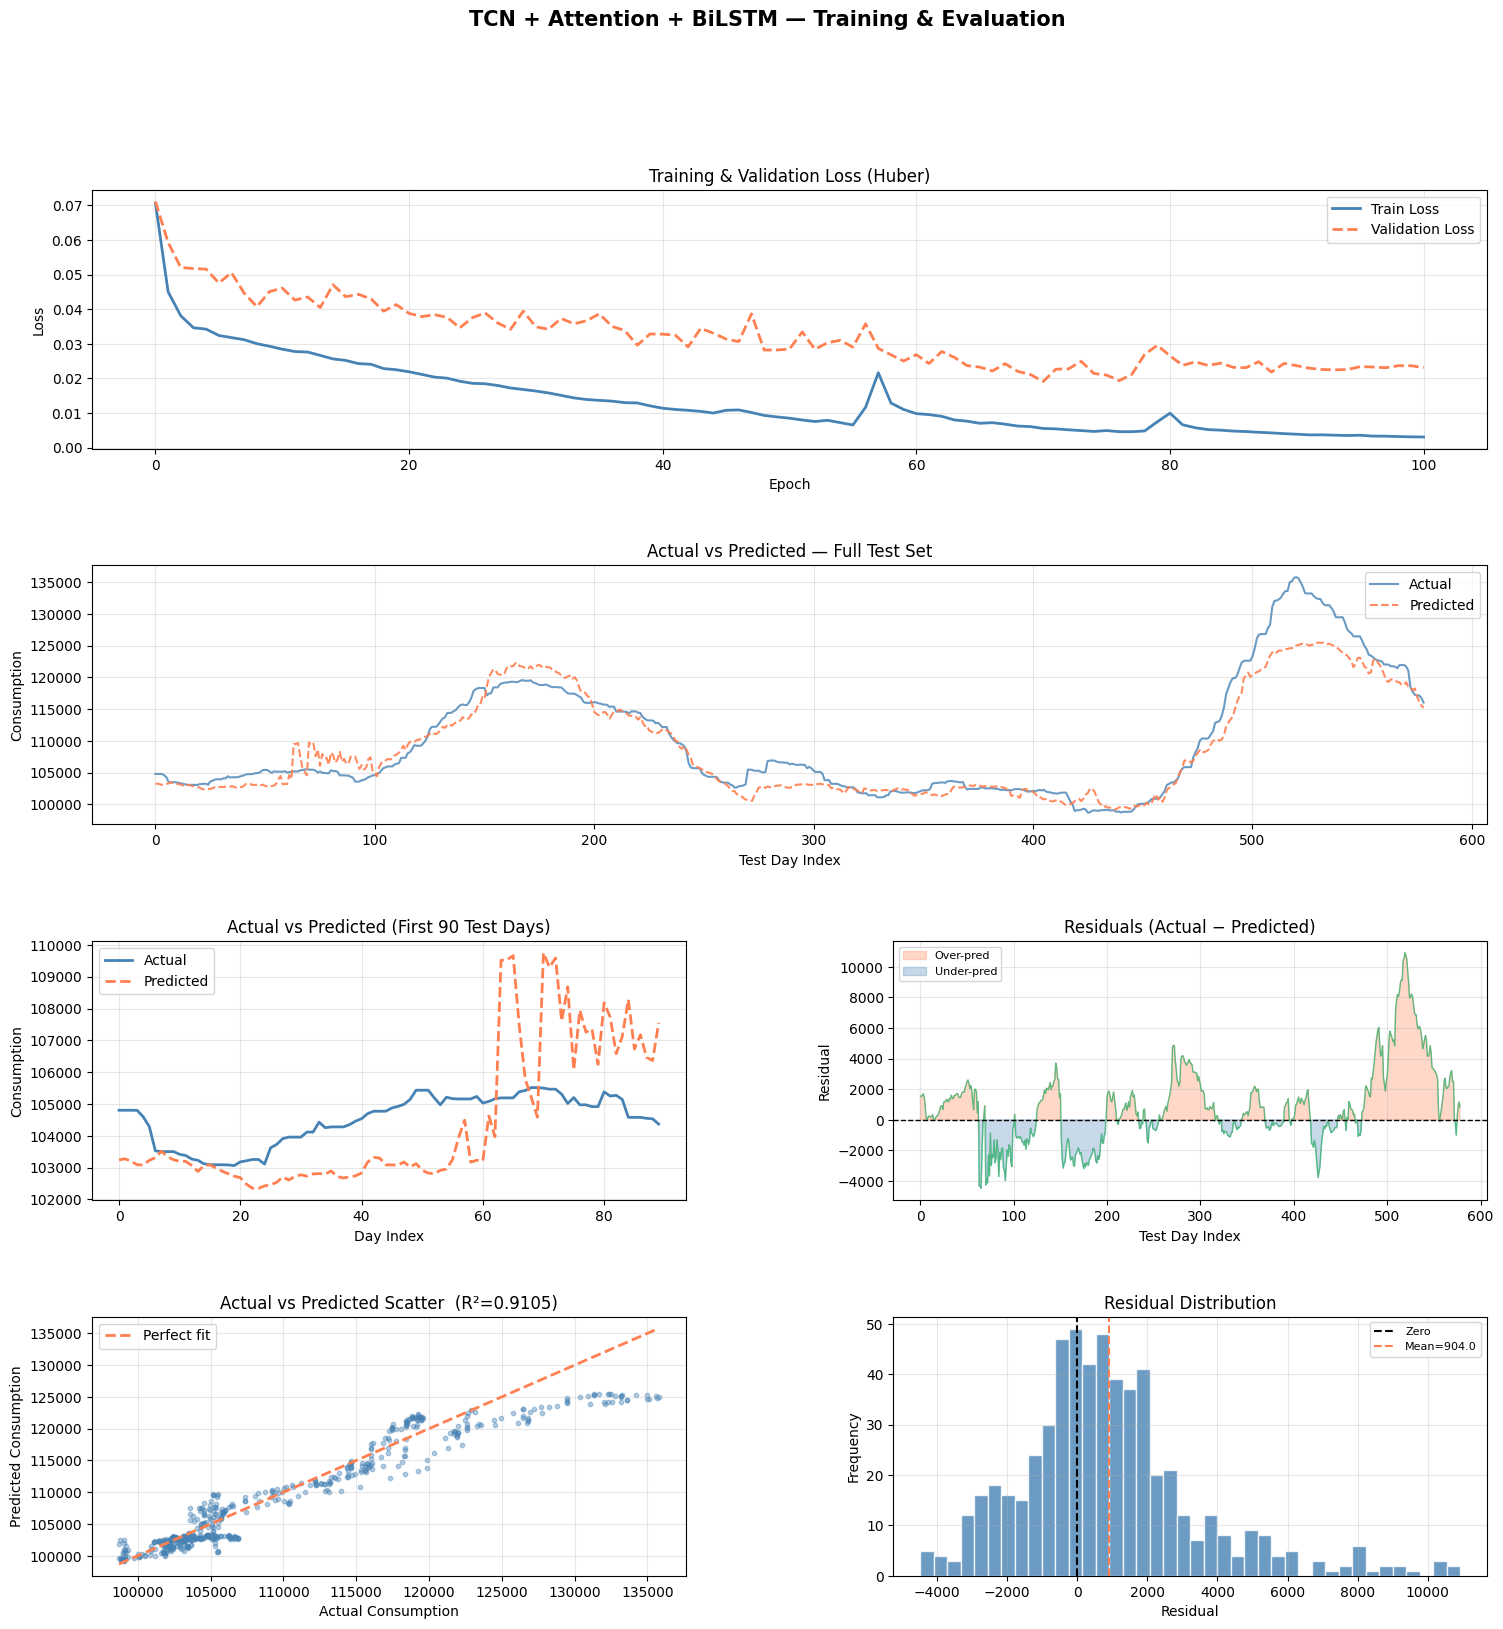

Results plot saved → tcn_bilstm_results.png


In [20]:
fig = plt.figure(figsize=(18, 18))
fig.suptitle('TCN + Attention + BiLSTM — Training & Evaluation',
             fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

# --- Loss curves ---
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(history.history['loss'],     label='Train Loss',      color='steelblue', lw=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', color='coral',     lw=2, linestyle='--')
ax1.set_title('Training & Validation Loss (Huber)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Full test set ---
ax2 = fig.add_subplot(gs[1, :])
ax2.plot(y_test_orig,  label='Actual',    color='steelblue', lw=1.5, alpha=0.8)
ax2.plot(y_pred_orig,  label='Predicted', color='coral',     lw=1.5, linestyle='--', alpha=0.9)
ax2.set_title('Actual vs Predicted — Full Test Set')
ax2.set_xlabel('Test Day Index')
ax2.set_ylabel('Consumption')
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- Zoomed ---
ax3 = fig.add_subplot(gs[2, 0])
ax3.plot(y_test_orig[:90], label='Actual',    color='steelblue', lw=2)
ax3.plot(y_pred_orig[:90], label='Predicted', color='coral',     lw=2, linestyle='--')
ax3.set_title('Actual vs Predicted (First 90 Test Days)')
ax3.set_xlabel('Day Index')
ax3.set_ylabel('Consumption')
ax3.legend()
ax3.grid(True, alpha=0.3)

# --- Residuals ---
ax4 = fig.add_subplot(gs[2, 1])
ax4.plot(residuals, color='mediumseagreen', lw=1, alpha=0.8)
ax4.axhline(0, color='black', lw=1, linestyle='--')
ax4.fill_between(range(len(residuals)), residuals, 0,
                 where=(residuals > 0), color='coral',     alpha=0.3, label='Over-pred')
ax4.fill_between(range(len(residuals)), residuals, 0,
                 where=(residuals < 0), color='steelblue', alpha=0.3, label='Under-pred')
ax4.set_title('Residuals (Actual − Predicted)')
ax4.set_xlabel('Test Day Index')
ax4.set_ylabel('Residual')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# --- Scatter ---
ax5 = fig.add_subplot(gs[3, 0])
ax5.scatter(y_test_orig, y_pred_orig, alpha=0.4, color='steelblue', s=10)
lo = min(y_test_orig.min(), y_pred_orig.min())
hi = max(y_test_orig.max(), y_pred_orig.max())
ax5.plot([lo, hi], [lo, hi], color='coral', lw=2, linestyle='--', label='Perfect fit')
ax5.set_title(f'Actual vs Predicted Scatter  (R²={r2:.4f})')
ax5.set_xlabel('Actual Consumption')
ax5.set_ylabel('Predicted Consumption')
ax5.legend()
ax5.grid(True, alpha=0.3)

# --- Residual histogram ---
ax6 = fig.add_subplot(gs[3, 1])
ax6.hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax6.axvline(0,               color='black', lw=1.5, linestyle='--', label='Zero')
ax6.axvline(residuals.mean(), color='coral', lw=1.5, linestyle='--',
            label=f'Mean={residuals.mean():.1f}')
ax6.set_title('Residual Distribution')
ax6.set_xlabel('Residual')
ax6.set_ylabel('Frequency')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

plt.savefig('tcn_bilstm_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results plot saved → tcn_bilstm_results.png")

### Final Performance Summary

In [21]:
print("\n" + "="*55)
print(f"{'FINAL MODEL PERFORMANCE':^55}")
print("="*55)
print(f"  {'Metric':<12} {'Value':>15}")
print("-"*55)
print(f"  {'MAE':<12} {mae:>15.4f}")
print(f"  {'RMSE':<12} {rmse:>15.4f}")
print(f"  {'R²':<12} {r2:>15.4f}")
print(f"  {'MAPE':<12} {mape:>14.2f}%")
print(f"  {'Max Error':<12} {max_err:>15.4f}")
print("="*55)


                FINAL MODEL PERFORMANCE                
  Metric                 Value
-------------------------------------------------------
  MAE                1944.2941
  RMSE               2742.1200
  R²                    0.9105
  MAPE                   1.69%
  Max Error         10918.6289
